In [ ]:
# =============================================================================
# 🎬 PROJECT: Movie Success Analysis
# =============================================================================

# 1. Монтируем Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile

# 3. Распаковываем архив
archive_path = '/content/drive/MyDrive/кино/archive.zip'
extract_path = '/content/data'
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(archive_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Архив распакован")

# 4. Загружаем данные
df_movies = pd.read_csv(f'{extract_path}/tmdb_5000_movies.csv')
df_credits = pd.read_csv(f'{extract_path}/tmdb_5000_credits.csv')

print(f"✅ Загружено фильмов: {len(df_movies)}")
print(f"✅ Записей о касте: {len(df_credits)}")

# 5. Первая проверка
print("\n📊 Первые 3 фильма:")
df_movies[['title', 'budget', 'revenue', 'vote_average']].head(3)

In [ ]:
# Посмотрим, какие файлы распаковались
files = os.listdir(extract_path)
print("Найдены файлы:", files)


print(f"\n✅ Датасет фильмов: {df_movies.shape[0]} строк, {df_movies.shape[1]} колонок")
print(f"✅ Датасет кредитов: {df_credits.shape[0]} строк, {df_credits.shape[1]} колонок")

# Показываем первые строки
print("\n📊 Пример данных (movies):")
df_movies.head(200)

In [ ]:
# 📊 Базовая информация
print("=== MOVIES DATASET ===")
print(f"Размер: {df_movies.shape}")
print(f"\nКолонки:\n{df_movies.columns.tolist()}")
print(f"\nПропуски (топ-10):\n{df_movies.isnull().sum().sort_values(ascending=False).head(10)}")

print("\n=== CREDITS DATASET ===")
print(f"Размер: {df_credits.shape}")
print(f"Колонки: {df_credits.columns.tolist()}")

In [ ]:
# Объединяем по movie_id
df = df_movies.merge(df_credits, left_on='id', right_on='movie_id', suffixes=('_movies', '_credits'))
df_clean = df[(df['budget'] > 0) & (df['revenue'] > 0)].copy()
df_clean = df_clean[df_clean['budget'] > 10000]


print(f"✅ Объединённый датасет: {df.shape}")
print(f"✅ Очищенный датасет: {df_clean.shape}")
df.head(2)

In [ ]:

def classify_success(row):
    if row['revenue'] == 0:
        return 'unknown'
    ratio = row['revenue'] / row['budget'] if row['budget'] > 0 else 0
    if ratio >= 2.5:
        return 'HIT'
    elif ratio >= 1.5:
        return 'BREAK_EVEN'
    else:
        return 'FLOP'

df_clean['log_revenue'] = np.log1p(df_clean['revenue'])
df_clean['success_category'] = df_clean.apply(classify_success, axis=1)

df_clean[['revenue', 'budget', 'log_revenue', 'success_category']].head()

print(f"✅ Объединённый датасет: {df.shape}")
print(f"✅ Очищенный датасет: {df_clean.shape}")

In [ ]:
Q1 = df_clean['revenue'].quantile(0.25)
Q3 = df_clean['revenue'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Нижняя граница:", lower_bound)
print("Верхняя граница:", upper_bound)

In [ ]:
df_no_outliers = df_clean[
    (df_clean['revenue'] >= lower_bound) &
    (df_clean['revenue'] <= upper_bound)
].copy()

In [ ]:
print("С выбросами:", df_clean.shape)
print("Без выбросов:", df_no_outliers.shape)

In [ ]:


print("📊 Распределение по категориям успеха:")
print(df_clean['success_category'].value_counts())

In [ ]:
import pandas as pd

# 1. Convert 'release_date' to datetime for both DataFrames
df_clean['release_date'] = pd.to_datetime(df_clean['release_date'], errors='coerce')

# 2. Extract temporal features for df_clean
df_clean['release_year'] = df_clean['release_date'].dt.year
df_clean['release_month'] = df_clean['release_date'].dt.month
df_clean['day_of_week'] = df_clean['release_date'].dt.dayofweek

# 3. Verify the extraction
print("✅ Temporal features extracted for both 'df_clean'.")
df_clean[['release_date', 'release_year', 'release_month', 'day_of_week']].head()

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(df_no_outliers['budget'], df_no_outliers['revenue'], alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Бюджет (без выбросов)')
plt.ylabel('Сборы (без выбросов)')
plt.title('Бюджет и сборы без выбросов')
plt.grid(True)
plt.show()

In [ ]:
year_stats = df_clean.groupby('release_year').agg(
    films_count=('title_movies', 'count'),
    revenue_sum=('revenue', 'sum'),
    revenue_mean=('revenue', 'mean'),
    revenue_median=('revenue', 'median')
).reset_index()

year_stats = year_stats[year_stats['release_year'] >= 1990]
print(year_stats.head())

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(year_stats['release_year'], year_stats['films_count'])
plt.title('Количество фильмов по годам')
plt.xlabel('Год')
plt.ylabel('Количество фильмов')
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(year_stats['release_year'], year_stats['revenue_mean'])
plt.title('Средняя выручка по годам')
plt.xlabel('Год')
plt.ylabel('Средняя выручка')
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(year_stats['release_year'], year_stats['revenue_median'])
plt.title('Медианная выручка по годам')
plt.xlabel('Год')
plt.ylabel('Медианная выручка')
plt.grid(True)
plt.show()

In [ ]:
import ast

# Извлекаем имя режиссёра (обычно первый в списке с job='Director')
def get_director(x):
    if pd.isna(x) or x == '[]':
        return 'Unknown'
    try:
        crew = ast.literal_eval(x)
        for person in crew:
            if person.get('job') == 'Director':
                return person['name']
        return 'Unknown'
    except:
        return 'Unknown'

df_clean['director'] = df_clean['crew'].apply(get_director)


def get_top_actors(x, n=3):
    if pd.isna(x) or x == '[]':
        return []
    try:
        cast = ast.literal_eval(x)
        # Сортируем
        sorted_cast = sorted(cast, key=lambda p: p.get('order', 999))
        return [p['name'] for p in sorted_cast[:n]]
    except:
        return []

df_clean['top_actors'] = df_clean['cast'].apply(get_top_actors)

print(f"✅ Режиссёр извлечён. Примеры:\n{df_clean[['title_movies', 'director']].head(5)}")

In [ ]:
import ast

# Функция для извлечения названий из JSON-строк
def parse_json_column(x, key='name'):
    if pd.isna(x) or x == '[]':
        return []
    try:
        return [item[key] for item in ast.literal_eval(x)]
    except:
        return []

# Применяем к жанрам
df_clean['genres_list'] = df_clean['genres'].apply(parse_json_column)
df_clean['main_genre'] = df_clean['genres_list'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')
df_clean['keywords_list'] = df_clean['keywords'].apply(parse_json_column)

# Проверяем результат
print("🎭 Топ-10 жанров:")
all_genres = [g for genre_list in df_clean['genres_list'] for g in genre_list]
pd.Series(all_genres).value_counts().head(10)

In [ ]:
# 🔗 Корреляция числовых признаков с выручкой
numeric_cols = ['budget', 'runtime', 'popularity', 'vote_average', 'vote_count', 'revenue']
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('📊 Корреляция признаков с кассовыми сборами')
plt.tight_layout()
plt.show()

# 💰 Бюджет vs Выручка (логарифмическая шкала)
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['budget'], df_clean['revenue'], alpha=0.3, s=10)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Бюджет ($)')
plt.ylabel('Выручка ($)')
plt.title('💎 Бюджет vs Выручка (лог-шкала)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 🎭 Средние сборы по жанрам (топ-10)
genre_revenue = (
    df_clean
    .explode('genres_list')
    .groupby('genres_list')['revenue']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
genre_revenue.plot(kind='barh')
plt.xlabel('Средняя выручка ($)')
plt.title('🎭 Топ-10 жанров по средним сборам')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Выбираем признаки для модели
features_to_use = [
    'budget', 'runtime', 'popularity', 'vote_average', 'vote_count',
    'release_year', 'release_month', 'day_of_week'
]


df_model = df_clean[features_to_use + ['log_revenue', 'success_category']].copy()


# Заполняем пропуски медианой
for col in features_to_use:
    if df_model[col].isnull().any():
        df_model[col] = df_model[col].fillna(df_model[col].median())

# Удаляем строки с пропущенной целевой
df_model = df_model.dropna(subset=['log_revenue'])

print(f"✅ Датасет для модели: {df_model.shape}")
print(f"🎯 Целевая переменная: log_revenue (регрессия) или success_category (классификация)")
df_model.head()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(df_clean['budget'], df_clean['revenue'], alpha=0.5)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Бюджет (лог шкала)')
plt.ylabel('Сборы (лог шкала)')
plt.title('Связь бюджета и сборов фильма')

plt.grid(True)
plt.show()

In [ ]:
colors = {
    'HIT': 'green',
    'BREAK_EVEN': 'orange',
    'FLOP': 'red'
}

plt.figure(figsize=(10,6))

for category in df_clean['success_category'].unique():
    subset = df_clean[df_clean['success_category'] == category]
    plt.scatter(subset['budget'], subset['revenue'],
                c=colors.get(category, 'gray'),
                label=category, alpha=0.5)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Бюджет (лог)')
plt.ylabel('Сборы (лог)')
plt.title('Бюджет vs Сборы с учетом успеха')

plt.legend()
plt.grid(True)
plt.show()

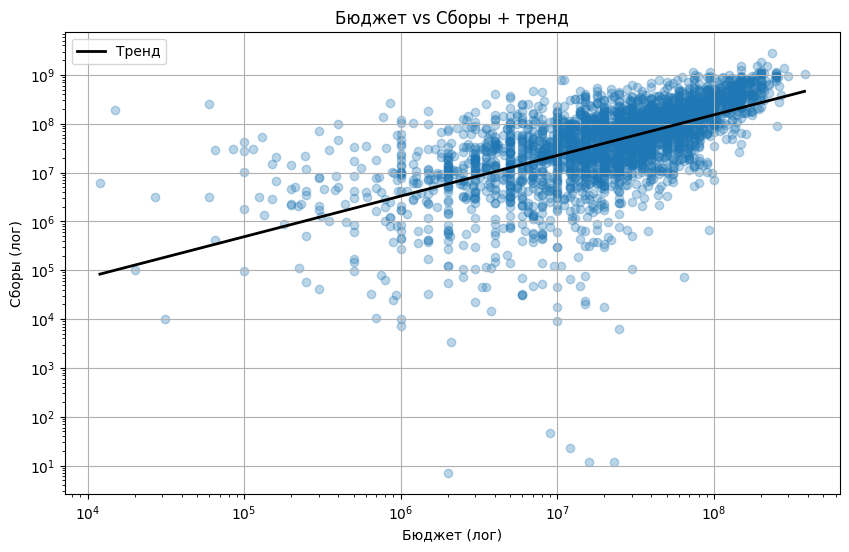

In [ ]:
import numpy as np

x = np.log10(df_clean['budget'])
y = np.log10(df_clean['revenue'])

coef = np.polyfit(x, y, 1)
poly = np.poly1d(coef)

plt.figure(figsize=(10,6))
plt.scatter(df_clean['budget'], df_clean['revenue'], alpha=0.3)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = poly(x_line)

plt.plot(10**x_line, 10**y_line, color='black', linewidth=2, label='Тренд')

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Бюджет (лог)')
plt.ylabel('Сборы (лог)')
plt.title('Бюджет vs Сборы + тренд')

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df_clean['ROI'] = df_clean['revenue'] / df_clean['budget']

df_clean[['title_movies', 'budget', 'revenue', 'ROI']].head()

,title_movies,budget,revenue,ROI
0,Avatar,237000000,2787965087,11.763566
1,Pirates of the Caribbean: At World's End,300000000,961000000,3.203333
2,Spectre,245000000,880674609,3.594590
3,The Dark Knight Rises,250000000,1084939099,4.339756
4,John Carter,260000000,284139100,1.092843


In [ ]:
df_clean['log_ROI'] = np.log1p(df_clean['ROI'])

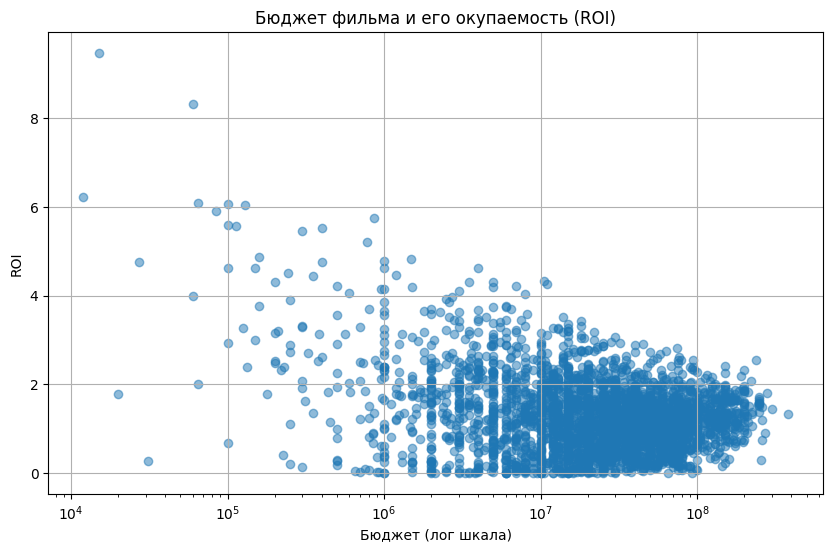

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(df_clean['budget'], df_clean['log_ROI'], alpha=0.5)

plt.xscale('log')

plt.xlabel('Бюджет (лог шкала)')
plt.ylabel('ROI')
plt.title('Бюджет фильма и его окупаемость (ROI)')

plt.grid(True)
plt.show()

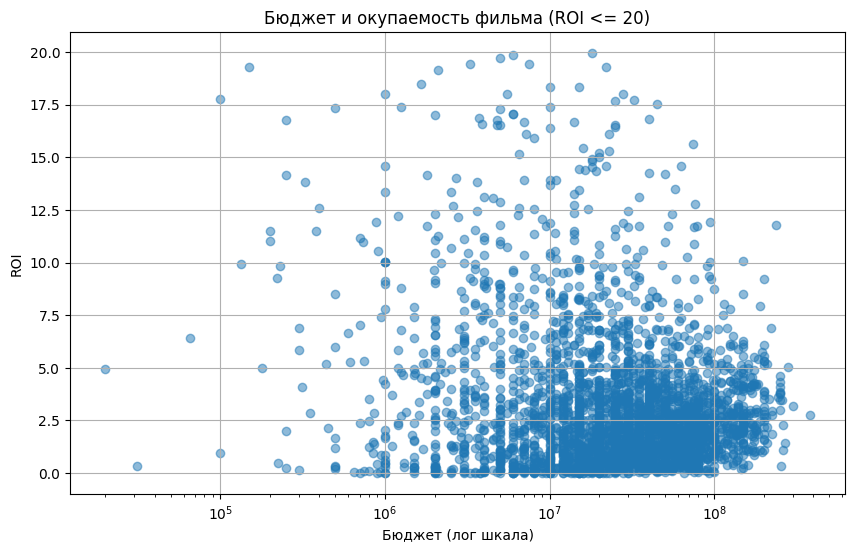

In [ ]:
df_roi = df_clean[df_clean['ROI'] <= 20].copy()

plt.figure(figsize=(10,6))
plt.scatter(df_roi['budget'], df_roi['ROI'], alpha=0.5)

plt.xscale('log')

plt.xlabel('Бюджет (лог шкала)')
plt.ylabel('ROI')
plt.title('Бюджет и окупаемость фильма (ROI <= 20)')

plt.grid(True)
plt.show()

In [ ]:
df_clean['ROI'] = df_clean['revenue'] / df_clean['budget']

print(df_clean[['title_movies', 'budget', 'revenue', 'ROI']].head())

                               title_movies     budget     revenue        ROI
0                                    Avatar  237000000  2787965087  11.763566
1  Pirates of the Caribbean: At World's End  300000000   961000000   3.203333
2                                   Spectre  245000000   880674609   3.594590
3                     The Dark Knight Rises  250000000  1084939099   4.339756
4                               John Carter  260000000   284139100   1.092843


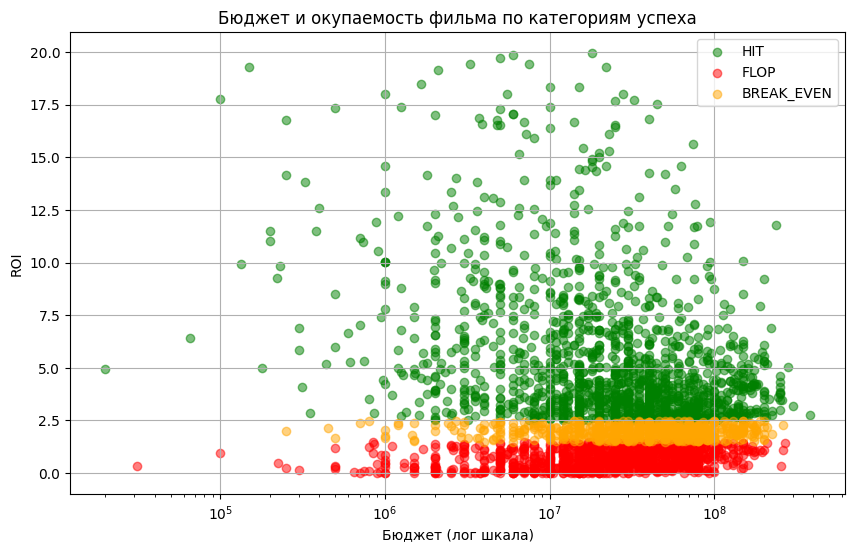

In [ ]:
colors = {
    'HIT': 'green',
    'BREAK_EVEN': 'orange',
    'FLOP': 'red'
}

df_roi = df_clean[df_clean['ROI'] <= 20].copy()

plt.figure(figsize=(10,6))

for category in df_roi['success_category'].unique():
    subset = df_roi[df_roi['success_category'] == category]
    plt.scatter(
    subset['budget'],
    subset['ROI'],
    c=colors.get(category, 'gray'),
    label=category,
    alpha=0.5
)


plt.xscale('log')

plt.xlabel('Бюджет (лог шкала)')
plt.ylabel('ROI')
plt.title('Бюджет и окупаемость фильма по категориям успеха')

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df_clean.sort_values('ROI', ascending=False)[['original_title', 'budget', 'revenue', 'ROI']].head(10)

,original_title,budget,revenue,ROI
4577,Paranormal Activity,15000,193355800,12890.386667
4496,The Blair Witch Project,60000,248000000,4133.333333
4788,Pink Flamingos,12000,6000000,500.000000
4742,Super Size Me,65000,28575078,439.616585
4723,The Gallows,100000,42664410,426.644100
4514,Open Water,130000,54667954,420.522723
3159,The Texas Chain Saw Massacre,85000,30859000,363.047059
4441,Bambi,858000,267447150,311.709965
4668,The Stewardesses,100000,27000000,270.000000
3737,Night of the Living Dead,114000,30000000,263.157895


In [ ]:
df_clean['budget_group'] = pd.qcut(
    df_clean['budget'],
    q=3,
    labels=['Low budget', 'Mid budget', 'High budget']
)

df_clean[['budget', 'budget_group']].head()

,budget,budget_group
0,237000000,High budget
1,300000000,High budget
2,245000000,High budget
3,250000000,High budget
4,260000000,High budget


In [ ]:
df_clean.groupby('budget_group')['budget'].agg(['min', 'median', 'max', 'count'])

/tmp/ipykernel_5450/2080156999.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby('budget_group')['budget'].agg(['min', 'median', 'max', 'count'])


,min,median,max,count
budget_group,,,,
Low budget,12000,6500000.0,15000000,1109
Mid budget,15500000,26000000.0,40000000,1035
High budget,40600000,73000000.0,380000000,1069


In [ ]:
budget_summary = df_clean.groupby('budget_group').agg(
    films_count=('budget_group', 'count'),
    median_budget=('budget', 'median'),
    median_revenue=('revenue', 'median'),
    median_roi=('ROI', 'median')
)

budget_summary

/tmp/ipykernel_5450/719099275.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  budget_summary = df_clean.groupby('budget_group').agg(


,films_count,median_budget,median_revenue,median_roi
budget_group,,,,
Low budget,1109,6500000.0,17273593.0,3.118040
Mid budget,1035,26000000.0,52277485.0,1.965000
High budget,1069,73000000.0,164508066.0,2.192626


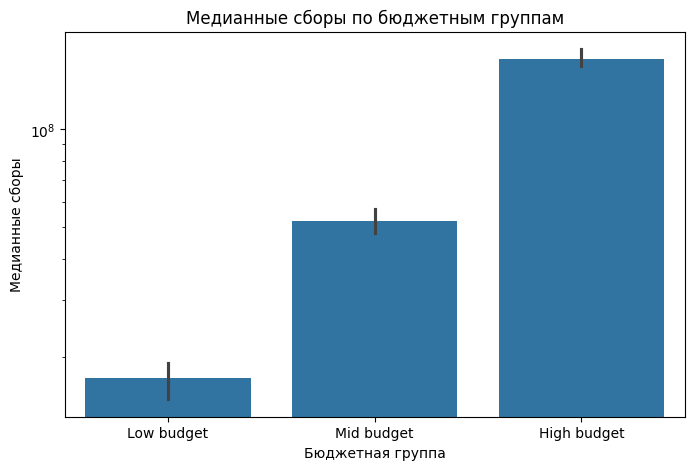

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df_clean,
    x='budget_group',
    y='revenue',
    estimator=np.median,
    order=['Low budget', 'Mid budget', 'High budget']
)
plt.yscale('log')
plt.title('Медианные сборы по бюджетным группам')
plt.xlabel('Бюджетная группа')
plt.ylabel('Медианные сборы')
plt.show()

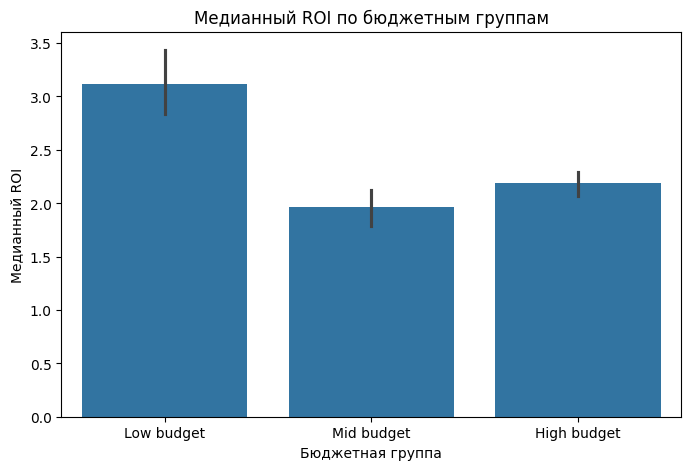

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df_clean,
    x='budget_group',
    y='ROI',
    estimator=np.median,
    order=['Low budget', 'Mid budget', 'High budget']
)
plt.title('Медианный ROI по бюджетным группам')
plt.xlabel('Бюджетная группа')
plt.ylabel('Медианный ROI')
plt.show()

In [ ]:
genre_stats = (
    df_clean.groupby('main_genre')
    .agg(
        films_count=('main_genre', 'count'),
        mean_revenue=('revenue', 'mean'),
        median_revenue=('revenue', 'median')
    )
    .sort_values('mean_revenue', ascending=False)
)

genre_stats.head(10)

,films_count,mean_revenue,median_revenue
main_genre,,,
Animation,99,2.989416e+08,245724603.0
Adventure,287,2.469419e+08,141195658.0
Family,38,2.340616e+08,95268400.5
Science Fiction,78,2.073831e+08,96492738.5
Fantasy,92,1.854043e+08,126038645.0
Action,588,1.555427e+08,72739356.0
History,18,1.007775e+08,44545847.0
Thriller,116,1.007504e+08,63236378.5
Romance,70,9.892815e+07,61274473.5


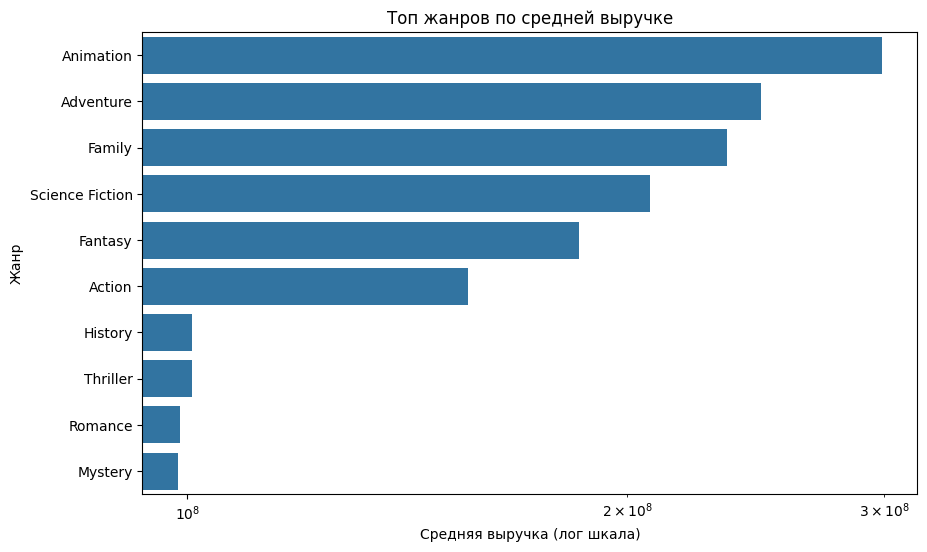

In [ ]:
top_mean = genre_stats.sort_values('mean_revenue', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_mean['mean_revenue'], y=top_mean.index)
plt.xscale('log')
plt.title('Топ жанров по средней выручке')
plt.xlabel('Средняя выручка (лог шкала)')
plt.ylabel('Жанр')
plt.show()

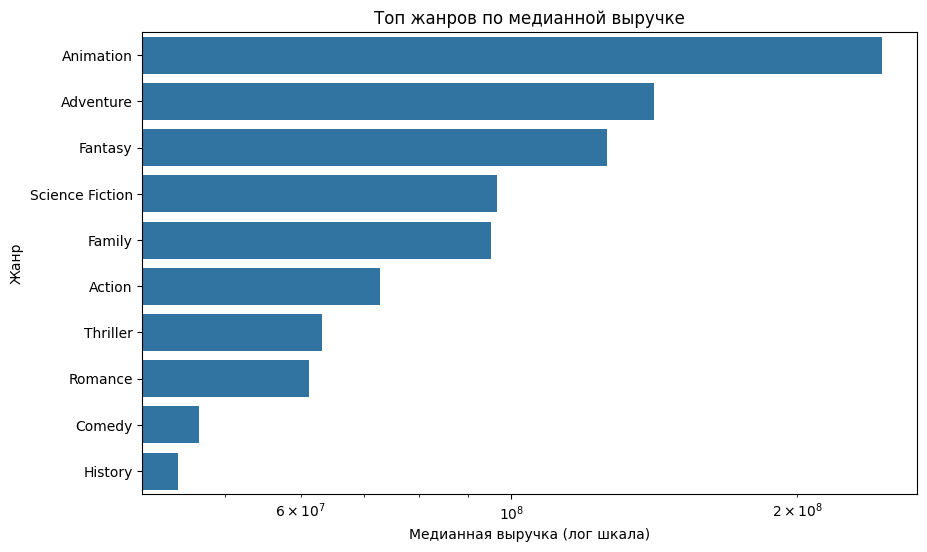

In [ ]:
top_median = genre_stats.sort_values('median_revenue', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_median['median_revenue'], y=top_median.index)
plt.xscale('log')
plt.title('Топ жанров по медианной выручке')
plt.xlabel('Медианная выручка (лог шкала)')
plt.ylabel('Жанр')
plt.show()

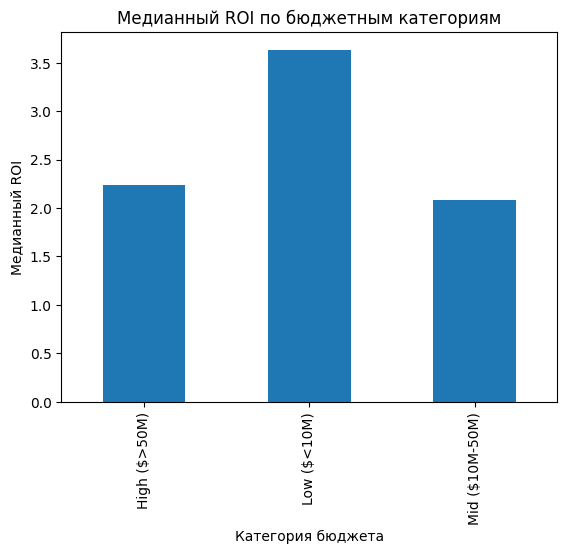

,ROI
budget_category,
High ($>50M),2.234364
Low ($<10M),3.632856
Mid ($10M-50M),2.086186


In [ ]:
# 1. Создаем категории
def categorize_budget(x):
    if x < 10_000_000: return 'Low ($<10M)'
    elif x <= 50_000_000: return 'Mid ($10M-50M)'
    else: return 'High ($>50M)'

df_clean['budget_category'] = df_clean['budget'].apply(categorize_budget)

# 2. Считаем медиану ROI для каждой группы
roi_comparison = df_clean.groupby('budget_category')['ROI'].median()

# 3. Строим Bar Chart
roi_comparison.plot(kind='bar')
plt.title('Медианный ROI по бюджетным категориям')
plt.xlabel('Категория бюджета')
plt.ylabel('Медианный ROI')
plt.show()
display(roi_comparison)

In [ ]:
def categorize_budget_v2(x):
    if x < 10_000_000:
        return '1. Low ($<10M)'
    elif x <= 100_000_000:
        return '2. Mid ($10M-$100M)'
    else:
        return '3. High ($>100M)'

df_clean['budget_category_v2'] = df_clean['budget'].apply(categorize_budget_v2)

# Считаем медиану ROI
new_stats = df_clean.groupby('budget_category_v2')['ROI'].median().round(2)
print("Новые показатели медианного ROI:")
print(new_stats)

Новые показатели медианного ROI:
budget_category_v2
1. Low ($<10M)         3.63
2. Mid ($10M-$100M)    2.06
3. High ($>100M)       2.76
Name: ROI, dtype: float64


In [ ]:
df_clean['loss'] = df_clean['budget'] - df_clean['revenue']

cult_flops_loss = df_clean[
    (df_clean['vote_average'] >= 7.5) &
    (df_clean['vote_count'] >= 1000) &
    (df_clean['ROI'] < 1)
][[
    'title_movies',
    'budget',
    'revenue',
    'loss',
    'ROI',
    'vote_average',
    'vote_count',
    'success_category'
]].copy()

cult_flops_loss = cult_flops_loss.sort_values(
    by='loss',
    ascending=False
)

cult_flops_loss

,title_movies,budget,revenue,loss,ROI,vote_average,vote_count,success_category
977,The Iron Giant,70000000,23159305,46840695,0.330847,7.6,1436,FLOP
1352,Gattaca,36000000,12532777,23467223,0.348133,7.5,1808,FLOP
3706,Donnie Darko,6000000,1270522,4729478,0.211754,7.7,3452,FLOP
1920,Warrior,25000000,23057115,1942885,0.922285,7.7,1272,FLOP


In [ ]:
# Культовые/высокооценённые, но финансово провальные фильмы

cult_flops = df_clean[
    (df_clean['vote_average'] >= 7.5) &
    (df_clean['vote_count'] >= 1000) &
    (df_clean['ROI'] < 1)
][[
    'title_movies',
    'budget',
    'revenue',
    'ROI',
    'vote_average',
    'vote_count',
    'success_category'
]].copy()

cult_flops = cult_flops.sort_values(
    by=['vote_average', 'ROI'],
    ascending=[False, True]
)

cult_flops.head(15)

,title_movies,budget,revenue,ROI,vote_average,vote_count,success_category
3706,Donnie Darko,6000000,1270522,0.211754,7.7,3452,FLOP
1920,Warrior,25000000,23057115,0.922285,7.7,1272,FLOP
977,The Iron Giant,70000000,23159305,0.330847,7.6,1436,FLOP
1352,Gattaca,36000000,12532777,0.348133,7.5,1808,FLOP


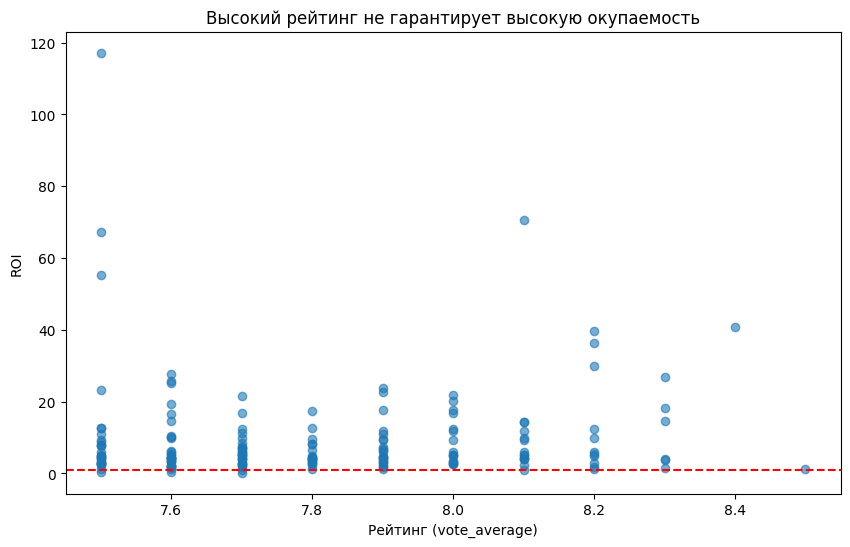

In [ ]:
plt.figure(figsize=(10,6))

subset = df_clean[
    (df_clean['vote_average'] >= 7.5) &
    (df_clean['vote_count'] >= 1000)
]

plt.scatter(subset['vote_average'], subset['ROI'], alpha=0.6)
plt.axhline(1, color='red', linestyle='--')

plt.title('Высокий рейтинг не гарантирует высокую окупаемость')
plt.xlabel('Рейтинг (vote_average)')
plt.ylabel('ROI')
plt.show()

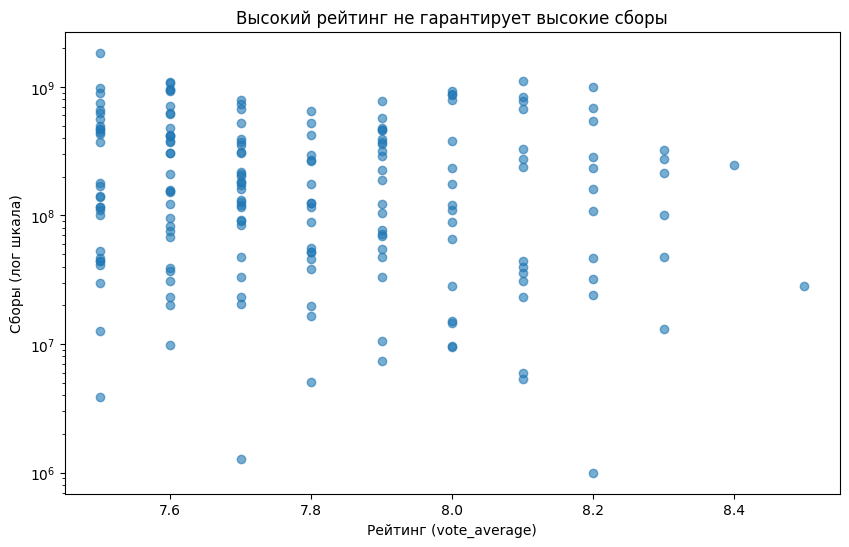

In [ ]:
subset = df_clean[
    (df_clean['vote_average'] >= 7.5) &
    (df_clean['vote_count'] >= 1000)
].copy()

plt.figure(figsize=(10,6))
plt.scatter(subset['vote_average'], subset['revenue'], alpha=0.6)

plt.yscale('log')

plt.title('Высокий рейтинг не гарантирует высокие сборы')
plt.xlabel('Рейтинг (vote_average)')
plt.ylabel('Сборы (лог шкала)')
plt.show()

In [ ]:
# Убираем мусор
df = df[(df['budget'] > 0) & (df['revenue'] > 0)]

# ROI (правильный!)
df['roi'] = (df['revenue'] - df['budget']) / df['budget']

In [ ]:
df['budget_group'] = pd.qcut(df['budget'], 3, labels=['low', 'mid', 'high'])

In [ ]:
from scipy import stats

corr_rev, p_rev = stats.spearmanr(df['budget'], df['revenue'])
corr_roi, p_roi = stats.spearmanr(df['budget'], df['roi'])

print("Budget vs Revenue:", corr_rev, p_rev)
print("Budget vs ROI:", corr_roi, p_roi)

Budget vs Revenue: 0.6785943125937096 0.0
Budget vs ROI: -0.1308624064759738 8.304227181432857e-14


In [ ]:
from scipy.stats import mannwhitneyu

low = df[df['budget_group'] == 'low']['roi']
high = df[df['budget_group'] == 'high']['roi']

stat, p = mannwhitneyu(low, high, alternative='greater')

print("p-value:", p)
print("Median low:", low.median())
print("Median high:", high.median())

p-value: 1.4295714605419062e-14
Median low: 2.1180401333333334
Median high: 1.1926264782608695


In [ ]:
print("p-value:", p)
print("Median low ROI:", low.median())
print("Median high ROI:", high.median())
print("Low count:", low.shape[0])
print("High count:", high.shape[0])

p-value: 1.4295714605419062e-14
Median low ROI: 2.1180401333333334
Median high ROI: 1.1926264782608695
Low count: 1125
High count: 1069


In [ ]:
from scipy.stats import kruskal

low = df[df['budget_group'] == 'low']['roi']
mid = df[df['budget_group'] == 'mid']['roi']
high = df[df['budget_group'] == 'high']['roi']

stat, p = kruskal(low, mid, high)
print("ROI p-value:", p)

ROI p-value: 1.8042108812103077e-19


In [ ]:
low_r = df[df['budget_group'] == 'low']['revenue']
mid_r = df[df['budget_group'] == 'mid']['revenue']
high_r = df[df['budget_group'] == 'high']['revenue']

stat, p = kruskal(low_r, mid_r, high_r)
print("Revenue p-value:", p)

Revenue p-value: 7.663626450524944e-269


In [ ]:
cult_flops = df[(df['vote_average'] > 7.5) & (df['revenue'] < df['budget'])]
cult_flops[['original_title', 'vote_average', 'revenue', 'budget']]

,original_title,vote_average,revenue,budget
977,The Iron Giant,7.6,23159305,70000000
1920,Warrior,7.7,23057115,25000000
2638,Metropolis,8.0,650422,92620000
2811,Ernest et Célestine,7.6,8109160,12516654
2898,南京!南京!,7.6,10652498,12000000
2947,The Visual Bible: The Gospel of John,8.2,4069090,10000000
2970,There Goes My Baby,8.5,123509,10500000
3296,アキラ,7.8,553171,8000000
3432,The Work and the Glory II: American Zion,8.0,2025032,6500000
3490,The Wild Bunch,7.6,638641,6244087


In [ ]:
cult_flops.sort_values('vote_average', ascending=False).head(10)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,tagline,title_movies,vote_average,vote_count,movie_id,title_credits,cast,crew,roi,budget_group
2970,10500000,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 35, ""name...",NaN,88641,[],en,There Goes My Baby,A group of high school seniors meets in the su...,0.037073,"[{""name"": ""Nelson Entertainment"", ""id"": 365}]",...,NaN,There Goes My Baby,8.5,2,88641,There Goes My Baby,"[{""cast_id"": 2, ""character"": ""Pirate"", ""credit...","[{""credit_id"": ""598db4fcc3a368758e01220c"", ""de...",-0.988237,low
2947,10000000,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 36, ""name...",NaN,30973,"[{""id"": 2618, ""name"": ""miracle""}, {""id"": 2974,...",en,The Visual Bible: The Gospel of John,A word for word depiction of the life of Jesus...,3.208172,"[{""name"": ""Gospel of John Ltd."", ""id"": 10167},...",...,For God loved the world So much...,The Visual Bible: The Gospel of John,8.2,12,30973,The Visual Bible: The Gospel of John,"[{""cast_id"": 1, ""character"": ""Narrator (voice)...","[{""credit_id"": ""52fe44519251416c9100c7cf"", ""de...",-0.593091,low
4535,2000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 18, ""nam...",NaN,346,"[{""id"": 233, ""name"": ""japan""}, {""id"": 1462, ""n...",ja,七人の侍,A samurai answers a village's request for prot...,39.756748,"[{""name"": ""Toho Company"", ""id"": 882}]",...,The Mighty Warriors Who Became the Seven Natio...,Seven Samurai,8.2,878,346,Seven Samurai,"[{""cast_id"": 13, ""character"": ""Kikuchiyo"", ""cr...","[{""credit_id"": ""52fe423bc3a36847f800dfef"", ""de...",-0.864080,low
3875,2000000,"[{""id"": 10749, ""name"": ""Romance""}, {""id"": 18, ...",NaN,108346,"[{""id"": 14794, ""name"": ""lust""}, {""id"": 160780,...",en,Dreaming of Joseph Lees,Set in rural England in the 1950s Eva (Samanth...,0.116150,"[{""name"": ""Fox Entertainment Group"", ""id"": 857...",...,NaN,Dreaming of Joseph Lees,8.0,1,108346,Dreaming of Joseph Lees,"[{""cast_id"": 5, ""character"": ""Joseph Lees"", ""c...","[{""credit_id"": ""52fe4a98c3a36847f81d7345"", ""de...",-0.999996,low
3432,6500000,"[{""id"": 18, ""name"": ""Drama""}]",http://www.workandtheglory.com/,14631,[],en,The Work and the Glory II: American Zion,"""The Work and The Glory: American Zion"" sets t...",2.639106,[],...,NaN,The Work and the Glory II: American Zion,8.0,6,14631,The Work and the Glory II: American Zion,"[{""cast_id"": 2, ""character"": ""Benjamin Steed"",...","[{""credit_id"": ""52fe460a9251416c7506b073"", ""de...",-0.688457,low
2638,92620000,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 878, ""nam...",NaN,19,"[{""id"": 312, ""name"": ""man vs machine""}, {""id"":...",de,Metropolis,In a futuristic city sharply divided between t...,32.351527,"[{""name"": ""Paramount Pictures"", ""id"": 4}, {""na...",...,There can be no understanding between the hand...,Metropolis,8.0,657,19,Metropolis,"[{""cast_id"": 10, ""character"": ""Maria"", ""credit...","[{""credit_id"": ""52fe420fc3a36847f8000c55"", ""de...",-0.992978,high
4521,2053648,"[{""id"": 99, ""name"": ""Documentary""}]",NaN,14271,"[{""id"": 5970, ""name"": ""wrestling""}, {""id"": 607...",en,Beyond the Mat,Beyond the Mat is a 1999 professional wrestlin...,2.778633,"[{""name"": ""Imagine Entertainment"", ""id"": 23}, ...",...,NaN,Beyond the Mat,7.8,17,14271,Beyond the Mat,"[{""cast_id"": 1, ""character"": ""Himself"", ""credi...","[{""credit_id"": ""58d5ec49c3a368127c03493c"", ""de...",-0.756531,low
3296,8000000,"[{""id"": 878, ""name"": ""Science Fiction""}, {""id""...",http://www.bandaivisual.co.jp/akira/,149,"[{""id"": 83, ""name"": ""saving the world""}, {""id""...",ja,アキラ,Childhood friends Tetsuo and Kaneda are pulled...,39.338097,"[{""name"": ""Bandai Visual Company"", ""id"": 528},...",...,Neo-Tokyo is about to E.X.P.L.O.D.E.,Akira,7.8,773,149,Akira,"[{""cast_id"": 4, ""character"": ""Sh\u00f4tar\u00f...","[{""credit_id"": ""52fe421ec3a36847f80057a9"", ""de...",-0.930854

In [ ]:
def classify(row):
    if row['roi'] > 1:
        return 'HIT'
    elif row['roi'] >= 0:
        return 'BREAK_EVEN'
    else:
        return 'FLOP'

df['success_category'] = df.apply(classify, axis=1)

In [ ]:
# 1. Если success_category еще нет
def classify(row):
    if row['ROI'] > 1:
        return 'HIT'
    elif row['ROI'] >= 0:
        return 'BREAK_EVEN'
    else:
        return 'FLOP'

df_clean['success_category'] = df_clean.apply(classify, axis=1)

# 2. Берем фильмы с большим бюджетом
sample = df_clean[(df_clean['budget'] >= 200000000) & (df_clean['budget'] <= 300000000)]

# 3. Берем примеры из каждой категории
result = pd.concat([
    sample[sample['success_category'] == 'HIT'].sort_values('budget').head(3),
    sample[sample['success_category'] == 'BREAK_EVEN'].sort_values('budget').head(3),
    sample[sample['success_category'] == 'FLOP'].sort_values('budget').head(3)
])[['original_title', 'budget', 'revenue', 'ROI', 'success_category']]

result

,original_title,budget,revenue,ROI,success_category
12,Pirates of the Caribbean: Dead Man's Chest,200000000,1065659812,5.328299,HIT
11,Quantum of Solace,200000000,586090727,2.930454,HIT
31,Iron Man 3,200000000,1215439994,6.077200,HIT
13,The Lone Ranger,255000000,89289910,0.350157,BREAK_EVEN


In [ ]:
# 1. Фильтруем только блокбастеры (бюджет > 150 млн)
high_budget_threshold = 150_000_000
big_movies = df[df['budget'] >= high_budget_threshold].copy()

# 2. Определяем примеры для каждой категории
# HIT: Высокий ROI (например, топ-3)
hits = big_movies.sort_values('roi', ascending=False).head(3)

# FLOP: Отрицательный или самый низкий ROI (бюджет не окупился)
flops = big_movies.sort_values('roi', ascending=True).head(3)

# BREAK EVEN: ROI около 1 (сборы примерно равны двум бюджетам — стандарт индустрии для окупаемости)
# Ищем фильмы, чей ROI близок к 1.0 (что значит Revenue = 2 * Budget)
break_even = big_movies[(big_movies['roi'] > 0.8) & (big_movies['roi'] < 1.2)].head(3)

# 3. Вывод результатов
print(f"--- ПРИМЕРЫ ДЛЯ ГИПОТЕЗЫ 1 (Бюджет > {high_budget_threshold/1000000:.0f} млн) ---")

print("\n✅ ХИТЫ (Высокая эффективность):")
print(hits[['original_title', 'budget', 'revenue', 'roi']])

print("\n❌ ПРОВАЛЫ (Бюджет не оправдался):")
print(flops[['original_title', 'budget', 'revenue', 'roi']])

print("\n⚖️ В НОЛЬ (Едва окупились):")
print(break_even[['original_title', 'budget', 'revenue', 'roi']])

--- ПРИМЕРЫ ДЛЯ ГИПОТЕЗЫ 1 (Бюджет > 150 млн) ---

✅ ХИТЫ (Высокая эффективность):
    original_title     budget     revenue        roi
0           Avatar  237000000  2787965087  10.763566
28  Jurassic World  150000000  1513528810   9.090192
25         Titanic  200000000  1845034188   8.225171

❌ ПРОВАЛЫ (Бюджет не оправдался):
       original_title     budget   revenue       roi
141   Mars Needs Moms  150000000  38992758 -0.740048
13    The Lone Ranger  255000000  89289910 -0.649843
208  The 13th Warrior  160000000  61698899 -0.614382

⚖️ В НОЛЬ (Едва окупились):
                              original_title     budget    revenue       roi
15  The Chronicles of Narnia: Prince Caspian  225000000  419651413  0.865117
23                        The Golden Compass  180000000  372234864  1.067971
33                     X-Men: The Last Stand  210000000  459359555  1.187426


In [ ]:
import pandas as pd

# Подготовим данные для вывода
def get_examples(group, condition, n=3):
    return df[df['vulnerability_group'] == group][condition].sort_values('roi', ascending=False).head(n)

# 1. Провалы в среднем бюджете (ROI < 1)
mid_flops = df[(df['vulnerability_group'] == 'Mid ($10M-$100M)') & (df['roi'] < 0)].sort_values('budget', ascending=False).head(5)

# 2. Хиты в среднем бюджете (ROI > 5)
mid_hits = df[(df['vulnerability_group'] == 'Mid ($10M-$100M)') & (df['roi'] > 5)].head(5)

# 3. Провалы в высоком бюджете для сравнения
high_flops = df[(df['vulnerability_group'] == 'High (>$100M)') & (df['roi'] < 0)].head(3)

print("❌ ПРИМЕРЫ ИЗ 'ОПАСНОЙ ЗОНЫ' (Mid-Budget Flops):")
display(mid_flops[['original_title', 'budget', 'revenue', 'roi']])

print("\n✅ ИСКЛЮЧЕНИЯ (Mid-Budget Hits):")
display(mid_hits[['original_title', 'budget', 'revenue', 'roi']])

print("\n📉 ДЛЯ СРАВНЕНИЯ: ДОРОГИЕ ПРОВАЛЫ (High-Budget Flops):")
display(high_flops[['original_title', 'budget', 'revenue', 'roi']])

KeyError: 'vulnerability_group'

In [ ]:
# 1. Фильтруем именно 'жертв' среднего бюджета (бюджет 30-100 млн, ROI < 0)
vulnerable_examples = df[
    (df['budget'] >= 30_000_000) &
    (df['budget'] <= 100_000_000) &
    (df['roi'] < -0.5)
].sort_values('budget', ascending=False).head(10)

# Форматируем для наглядности
vulnerable_table = vulnerable_examples[['original_title', 'budget', 'revenue', 'roi']].copy()
vulnerable_table['budget'] = vulnerable_table['budget'].apply(lambda x: f'${x/10**6:.1f}M')
vulnerable_table['revenue'] = vulnerable_table['revenue'].apply(lambda x: f'${x/10**6:.1f}M')
vulnerable_table['roi'] = vulnerable_table['roi'].apply(lambda x: f'{x*100:.1f}%')

print("⚠️ ПРИМЕРЫ ПОДТВЕРЖДАЮЩИЕ УЯЗВИМОСТЬ СРЕДНЕГО БЮДЖЕТА:")
print("(Крупные вложения с потерей более 50% бюджета)")
display(vulnerable_table)

### Почему эти примеры подтверждают гипотезу?

1.  **Большие абсолютные потери:** Провал фильма с бюджетом $80M-100M (как *Stealth* или *Final Fantasy*) наносит студии серьезный удар, в отличие от малобюджетных провалов.
2.  **Отсутствие 'защиты блокбастера':** У этих фильмов не хватило маркетингового веса или франшизной узнаваемости, чтобы вытянуть сборы, как это часто случается с фильмами за $200M+.
3.  **Высокая концентрация:** Как мы видели на графике ранее, почти 49% фильмов в этом сегменте не окупаются, и эти примеры — верхушка айсберга.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Определяем категории бюджетов
def categorize_budget_vulnerability(x):
    if x < 10_000_000: return 'Low (<$10M)'
    elif x <= 100_000_000: return 'Mid ($10M-$100M)'
    else: return 'High (>$100M)'

df['vulnerability_group'] = df['budget'].apply(categorize_budget_vulnerability)

# 2. Считаем процент провалов (ROI < 1) в каждой группе
# ROI < 1 означает, что выручка меньше бюджета
vulnerability_stats = df.groupby('vulnerability_group').agg(
    total_films=('roi', 'count'),
    flops=('roi', lambda x: (x < 1).sum())
).reset_index()

vulnerability_stats['flop_rate_%'] = (vulnerability_stats['flops'] / vulnerability_stats['total_films'] * 100).round(2)

# 3. Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(data=vulnerability_stats, x='vulnerability_group', y='flop_rate_%', hue='vulnerability_group', palette='magma', legend=False)

plt.title('Доля убыточных фильмов по бюджетным категориям (ROI < 1)')
plt.ylabel('Процент провалов (%)')
plt.xlabel('Категория бюджета')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, row in vulnerability_stats.iterrows():
    plt.text(i, row['flop_rate_%'] + 1, f"{row['flop_rate_%']}%", ha='center', fontweight='bold')

plt.show()

display(vulnerability_stats)

In [ ]:
# 1. Фильтруем фильмы с бюджетом от $10,000 до $500,000
min_budget = 10_000
low_budget_threshold = 500_000
low_budget_stars = df[(df['budget'] >= min_budget) & (df['budget'] <= low_budget_threshold)].copy()

# 2. Выбираем топ-10 самых успешных по ROI
low_budget_stars = low_budget_stars.sort_values('roi', ascending=False).head(10)

# 3. Форматируем вывод
output_low_budget = low_budget_stars[['original_title', 'budget', 'revenue', 'roi']].copy()
output_low_budget['budget'] = output_low_budget['budget'].apply(lambda x: f'${x:,.0f}')
output_low_budget['revenue'] = output_low_budget['revenue'].apply(lambda x: f'${x:,.0f}')
output_low_budget['roi'] = output_low_budget['roi'].round(2)

print(f'--- ТОП-10 МАЛОБЮДЖЕТНЫХ ФЕНОМЕНОВ (${min_budget/1000:.0f}k <= Бюджет <= ${low_budget_threshold/1000:.0f}k) ---')
display(output_low_budget)